# Binary Skin Lesion Classification: Curated vs. Uncurated Datasets

This notebook trains and evaluates convolutional neural networks for binary classification of skin lesion images as benign or malignant.

Two models are compared:

- A model trained on the original uncurated dataset
- A model trained on a curated version of the dataset

The workflow includes model training, test-set evaluation, confusion matrices, and classification metrics. GradCAM visualisation was also used to highlight the regions which influenced the model's predictions. This was developed by another team member and is provided separately in the notebook named "other-contributions.ipynb".

## Requirements

- Google Colab with GPU acceleration
- TensorFlow/Keras
- Curated and uncurated datasets stored in Google Drive

In [10]:
# IMPORTS

from pathlib import Path
import json

import matplotlib.cm as mpl_cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    img_to_array,
    load_img,
)

# Mount Google Drive
drive.mount("/content/drive")

# Change only this path to match your Google Drive folder
PROJECT_DIR = Path("/content/drive/MyDrive")

UNCURATED_DIR = PROJECT_DIR / "dataset_uncurated"
CURATED_DIR = PROJECT_DIR / "dataset_curated"
OUTPUT_DIR = PROJECT_DIR / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# CONFIGURATIONS

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 25
THRESHOLD = 0.5
SEED = 42

MODEL_TAG = f"{EPOCHS}epochs"

UNCURATED_MODEL_PATH = OUTPUT_DIR / f"cnn_uncurated_{MODEL_TAG}.keras"
CURATED_MODEL_PATH = OUTPUT_DIR / f"cnn_curated_{MODEL_TAG}.keras"

UNCURATED_HISTORY_PATH = OUTPUT_DIR / f"history_uncurated_{MODEL_TAG}.json"
CURATED_HISTORY_PATH = OUTPUT_DIR / f"history_curated_{MODEL_TAG}.json"

tf.keras.utils.set_random_seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# DATA GENERATORS

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(rescale=1./255)

def make_generators(base_dir):
    train_gen = train_datagen.flow_from_directory(
        str(base_dir / "Training"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=True,
        seed=SEED,
    )

    val_gen = val_datagen.flow_from_directory(
        str(base_dir / "Validation"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False,
    )

    return train_gen, val_gen

In [12]:
# CNN ARCHITECTURE

def build_model():
    model = models.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [13]:
# CALLBACKS

def make_callbacks():
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    )

    return [reduce_lr]

In [14]:
# PLOT FUNCTION

def plot_history(history, label, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
    f"CNN Training — {label} ({EPOCHS} Epochs)",
    fontsize=13,
    fontweight="bold",
)
    axes[0].plot(history.history['accuracy'],     'r--', label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], 'r-',  label='Val Accuracy')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     'b--', label='Train Loss')
    axes[1].plot(history.history['val_loss'], 'b-',  label='Val Loss')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

# COMBINED PLOT

def plot_combined(hist_unc, hist_cur):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
    f"{EPOCHS}-Epoch Comparison — Curated vs Uncurated",
    fontsize=13,
    fontweight="bold",
)

    # Accuracy
    axes[0].plot(hist_unc.history['accuracy'],     'r--', label='Uncurated - Train')
    axes[0].plot(hist_unc.history['val_accuracy'], 'r-',  label='Uncurated - Val')
    axes[0].plot(hist_cur.history['accuracy'],     'b--', label='Curated - Train')
    axes[0].plot(hist_cur.history['val_accuracy'], 'b-',  label='Curated - Val')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(hist_unc.history['loss'],     'r--', label='Uncurated - Train')
    axes[1].plot(hist_unc.history['val_loss'], 'r-',  label='Uncurated - Val')
    axes[1].plot(hist_cur.history['loss'],     'b--', label='Curated - Train')
    axes[1].plot(hist_cur.history['val_loss'], 'b-',  label='Curated - Val')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
    OUTPUT_DIR / f"training_curves_combined_{MODEL_TAG}.png",
    dpi=300,
    bbox_inches="tight",
)
    plt.show()


════ Training Uncurated Model ════
Found 2965 images belonging to 2 classes.
Found 1038 images belonging to 2 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,153 (17.49 MB)

 Trainable params: 4,584,193 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 623s 7s/step - accuracy: 0.7012 - loss: 0.7549 - val_accuracy: 0.3536 - val_loss: 2.1981 - learning_rate: 1.0000e-04
Epoch 2/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 55s 593ms/step - accuracy: 0.7366 - loss: 0.5242 - val_accuracy: 0.3536 - val_loss: 3.0180 - learning_rate: 1.0000e-04
Epoch 3/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 53s 573ms/step - accuracy: 0.7531 - loss: 0.5177 - val_accuracy: 0.3536 - val_loss: 4.1017 - learning_rate: 1.0000e-04
Epoch 4/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 53s 573ms/step - accuracy: 0.7710 - loss: 0.4840 - val_accuracy: 0.3796 - val_loss: 1.9538 - learning_rate: 1.0000e-04
Epoch 5/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 54s 582ms/step - accuracy: 0.7626 - loss: 0.4765 - val_accuracy: 0.5886 - val_loss: 0.9173 - learning_rate: 1.0000e-04
Epoch 6/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 53s 575ms/step - accuracy: 0.7676 - loss: 0.4801 - val_accuracy: 0.7746 - val_loss: 0.4629 - learning_rate: 1.0000e-04
Epoch 7/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 52s 561ms/step - accur

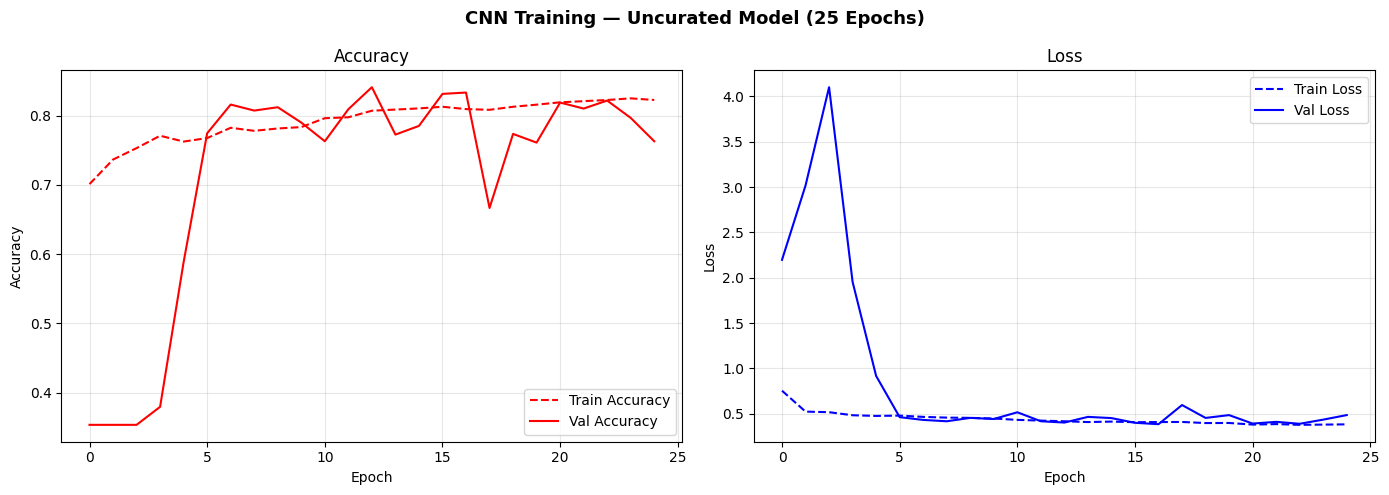


Uncurated — Best val accuracy: 84.10%
Uncurated — Epochs run: 25 / 25


In [15]:
# TRAIN UNCURATED

print('\n════ Training Uncurated Model ════')
unc_train, unc_val = make_generators(UNCURATED_DIR)
model_uncurated = build_model()
model_uncurated.summary()

history_uncurated = model_uncurated.fit(
    unc_train,
    validation_data=unc_val,
    epochs=EPOCHS,
    callbacks=make_callbacks()
)

model_uncurated.save(UNCURATED_MODEL_PATH)

with open(UNCURATED_HISTORY_PATH, "w") as file:
    json.dump(history_uncurated.history, file)

plot_history(
    history_uncurated,
    "Uncurated Model",
    OUTPUT_DIR / f"training_curves_uncurated_{MODEL_TAG}.png",
)

print(f'\nUncurated — Best val accuracy: {max(history_uncurated.history["val_accuracy"])*100:.2f}%')
print(f'Uncurated — Epochs run: {len(history_uncurated.history["accuracy"])} / {EPOCHS}')


════ Training Curated Model ════
Found 2955 images belonging to 2 classes.
Found 976 images belonging to 2 classes.
Epoch 1/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 707s 8s/step - accuracy: 0.6650 - loss: 0.8354 - val_accuracy: 0.6240 - val_loss: 1.2737 - learning_rate: 1.0000e-04
Epoch 2/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.7042 - loss: 0.5712 - val_accuracy: 0.6240 - val_loss: 1.5873 - learning_rate: 1.0000e-04
Epoch 3/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.7120 - loss: 0.5718 - val_accuracy: 0.6270 - val_loss: 1.1671 - learning_rate: 1.0000e-04
Epoch 4/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.7164 - loss: 0.5571 - val_accuracy: 0.6814 - val_loss: 0.9243 - learning_rate: 1.0000e-04
Epoch 5/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.7225 - loss: 0.5565 - val_accuracy: 0.7234 - val_loss: 0.5675 - learning_rate: 1.0000e-04
Epoch 6/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.7343 - loss: 0.5324 - val_accuracy: 0.7531 

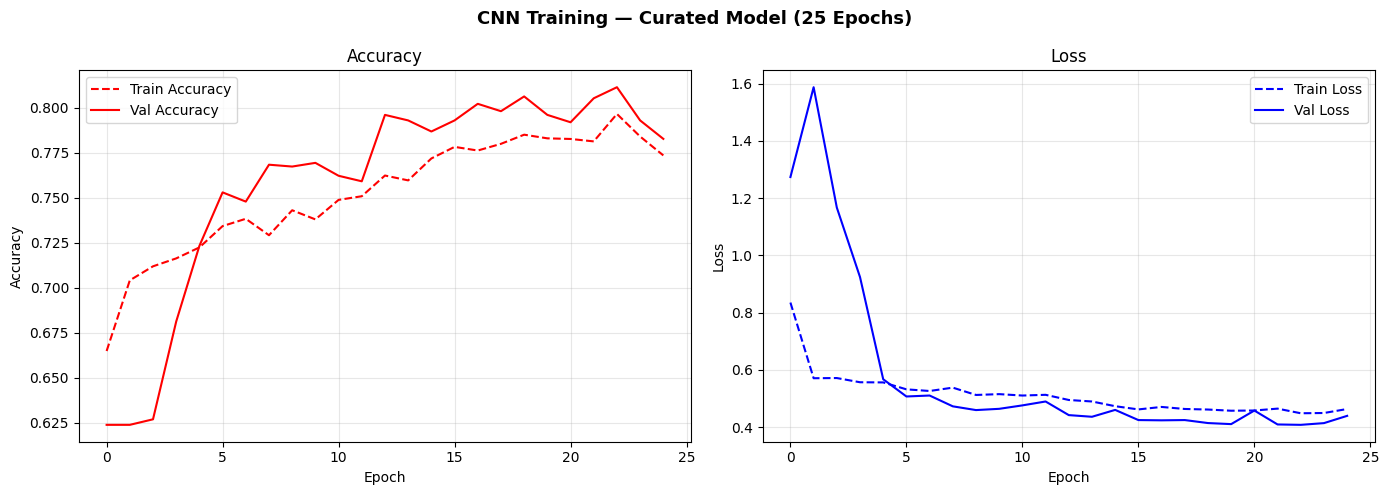


Curated — Best val accuracy: 81.15%
Curated — Epochs run: 25 / 25


In [16]:
# TRAIN CURATED

print('\n════ Training Curated Model ════')
cur_train, cur_val = make_generators(CURATED_DIR)
model_curated = build_model()

history_curated = model_curated.fit(
    cur_train,
    validation_data=cur_val,
    epochs=EPOCHS,
    callbacks=make_callbacks()
)

model_curated.save(CURATED_MODEL_PATH)

with open(CURATED_HISTORY_PATH, "w") as file:
    json.dump(history_curated.history, file)

plot_history(
    history_curated,
    "Curated Model",
    OUTPUT_DIR / f"training_curves_curated_{MODEL_TAG}.png",
)

print(f'\nCurated — Best val accuracy: {max(history_curated.history["val_accuracy"])*100:.2f}%')
print(f'Curated — Epochs run: {len(history_curated.history["accuracy"])} / {EPOCHS}')


════ Generating Combined Plot ════


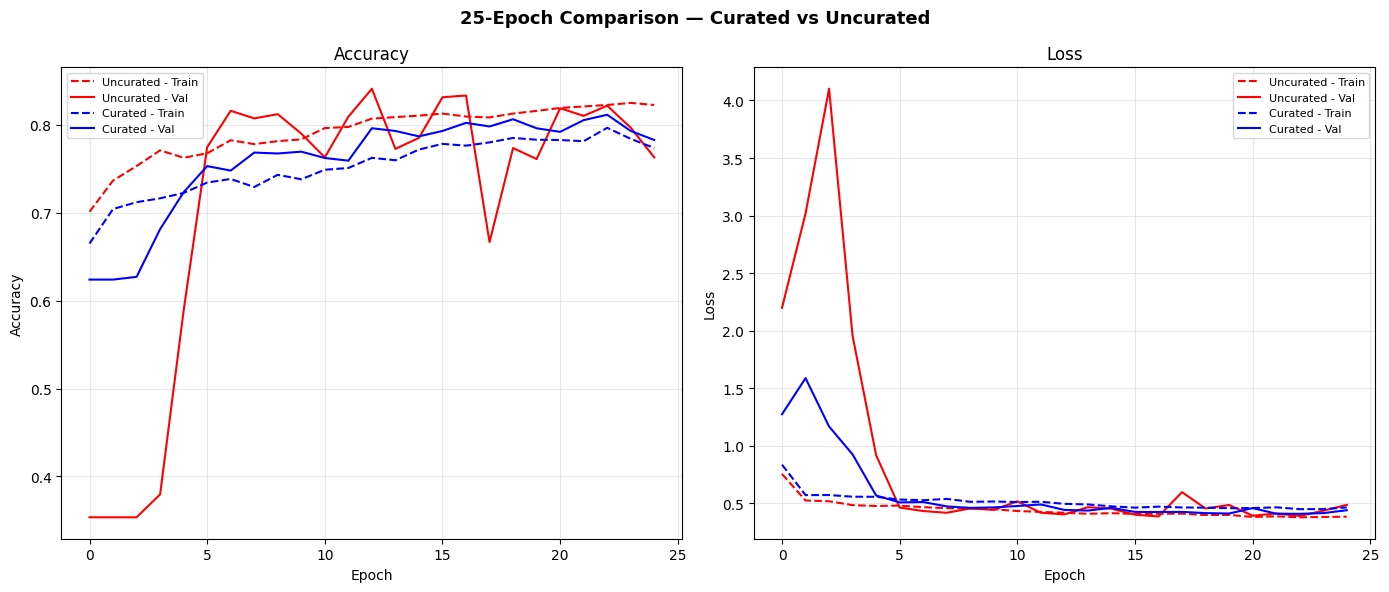


════ TRAINING COMPLETE ════
Uncurated — Best val accuracy: 84.10%
Curated   — Best val accuracy: 81.15%

Files saved:
  cnn_uncurated_25epochs.keras
  cnn_curated_25epochs.keras
  history_uncurated_25epochs.json
  history_curated_25epochs.json
  training_curves_uncurated_25epochs.png
  training_curves_curated_25epochs.png
  training_curves_combined_25epochs.png


In [17]:
# COMBINED COMPARISON PLOT

print('\n════ Generating Combined Plot ════')
plot_combined(history_uncurated, history_curated)

# SUMMARY

print('\n════ TRAINING COMPLETE ════')
print(f'Uncurated — Best val accuracy: {max(history_uncurated.history["val_accuracy"])*100:.2f}%')
print(f'Curated   — Best val accuracy: {max(history_curated.history["val_accuracy"])*100:.2f}%')
saved_files = [
    UNCURATED_MODEL_PATH,
    CURATED_MODEL_PATH,
    UNCURATED_HISTORY_PATH,
    CURATED_HISTORY_PATH,
    OUTPUT_DIR / f"training_curves_uncurated_{MODEL_TAG}.png",
    OUTPUT_DIR / f"training_curves_curated_{MODEL_TAG}.png",
    OUTPUT_DIR / f"training_curves_combined_{MODEL_TAG}.png",
]

print("\nFiles saved:")
for path in saved_files:
    print(f"  {path.name}")

In [18]:
# TESTING

# CONFIGURATIONS

CURATED_TEST_DIR = CURATED_DIR / "Test"
UNCURATED_TEST_DIR = UNCURATED_DIR / "Test"

# DATA GENERATORS

def make_test_generator(data_dir):
    datagen = ImageDataGenerator(rescale=1./255)
    return datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

curated_test   = make_test_generator(CURATED_TEST_DIR)
uncurated_test = make_test_generator(UNCURATED_TEST_DIR)

print(f'Curated   — {len(curated_test.classes)} samples | {curated_test.class_indices}')
print(f'Uncurated — {len(uncurated_test.classes)} samples | {uncurated_test.class_indices}')

# LOAD MODELS

curated_model   = load_model(CURATED_MODEL_PATH)
uncurated_model = load_model(UNCURATED_MODEL_PATH)

# PREDICTIONS

print('\nRunning predictions...')
curated_probs   = curated_model.predict(curated_test,   verbose=1).ravel()
uncurated_probs = uncurated_model.predict(uncurated_test, verbose=1).ravel()

curated_preds = (curated_probs >= THRESHOLD).astype(int)
uncurated_preds = (uncurated_probs >= THRESHOLD).astype(int)

curated_labels   = curated_test.classes
uncurated_labels = uncurated_test.classes

Found 533 images belonging to 2 classes.
Found 533 images belonging to 2 classes.
Curated   — 533 samples | {'Benign': 0, 'Malignant': 1}
Uncurated — 533 samples | {'Benign': 0, 'Malignant': 1}

Running predictions...
17/17 ━━━━━━━━━━━━━━━━━━━━ 78s 5s/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 98s 6s/step



Curated   — Sensitivity: 0.313 | Specificity: 0.827 | F1: 0.446 | Accuracy: 0.492
Uncurated — Sensitivity: 0.707 | Specificity: 0.784 | F1: 0.776 | Accuracy: 0.734


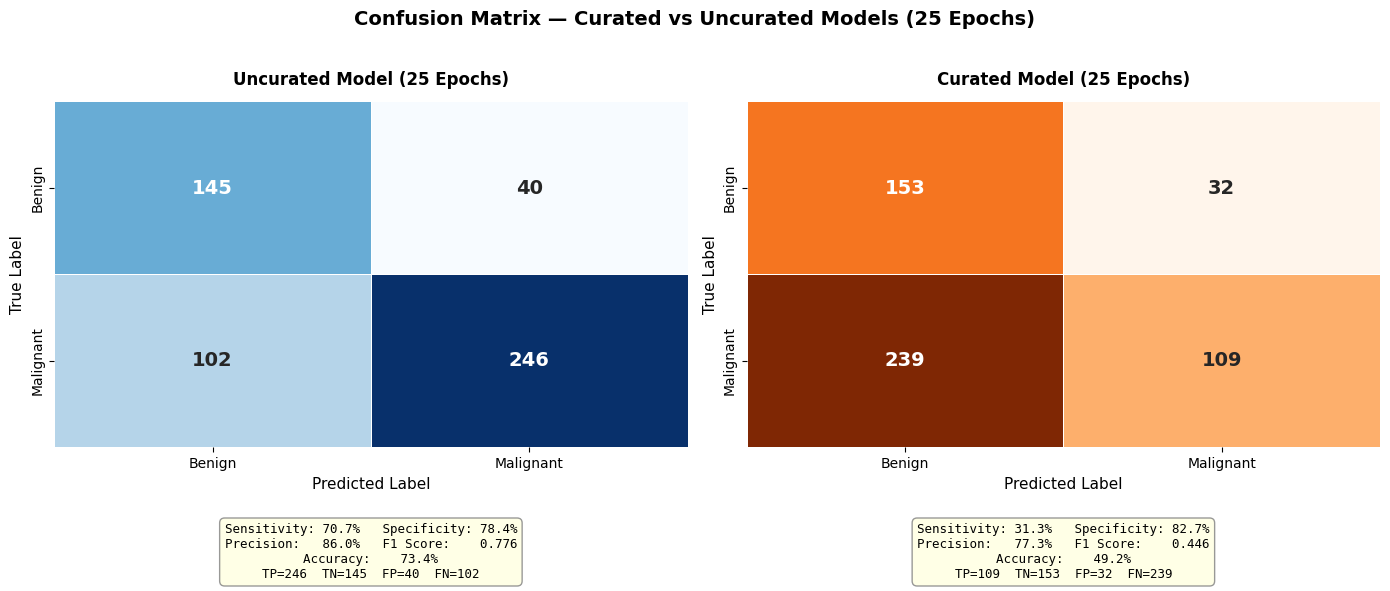

In [19]:
# CONFUSION MATRICES

cm_c = confusion_matrix(curated_labels,   curated_preds)
cm_u = confusion_matrix(uncurated_labels, uncurated_preds)

# METRICS

def get_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1          = 2 * precision * sensitivity / (precision + sensitivity) \
                  if (precision + sensitivity) > 0 else 0
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    return tn, fp, fn, tp, sensitivity, specificity, precision, f1, accuracy

tn_c, fp_c, fn_c, tp_c, sens_c, spec_c, prec_c, f1_c, acc_c = get_metrics(cm_c)
tn_u, fp_u, fn_u, tp_u, sens_u, spec_u, prec_u, f1_u, acc_u = get_metrics(cm_u)

print(f'\nCurated   — Sensitivity: {sens_c:.3f} | Specificity: {spec_c:.3f} | '
      f'F1: {f1_c:.3f} | Accuracy: {acc_c:.3f}')
print(f'Uncurated — Sensitivity: {sens_u:.3f} | Specificity: {spec_u:.3f} | '
      f'F1: {f1_u:.3f} | Accuracy: {acc_u:.3f}')

# PLOT

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Confusion Matrix — Curated vs Uncurated Models ({EPOCHS} Epochs)",
             fontsize=14, fontweight='bold', y=1.02)

class_names = ['Benign', 'Malignant']

for ax, matrix, title, colour, metrics in [
    (axes[0], cm_u, f"Uncurated Model ({EPOCHS} Epochs)", "Blues",
     (sens_u, spec_u, prec_u, f1_u, acc_u,
      tp_u, tn_u, fp_u, fn_u)),
    (axes[1], cm_c, f"Curated Model ({EPOCHS} Epochs)", "Oranges",
     (sens_c, spec_c, prec_c, f1_c, acc_c,
      tp_c, tn_c, fp_c, fn_c)),
]:
    sens, spec, prec, f1, acc, tp, tn, fp, fn = metrics

    sns.heatmap(
    matrix, annot=True, fmt='d', cmap=colour,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax, linewidths=0.5,
        annot_kws={'size': 14, 'weight': 'bold'},
        cbar=False
    )

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    ax.tick_params(labelsize=10)

    # Metrics box below the heatmap
    metrics_text = (
        f'Sensitivity: {sens:.1%}   Specificity: {spec:.1%}\n'
        f'Precision:   {prec:.1%}   F1 Score:    {f1:.3f}\n'
        f'Accuracy:    {acc:.1%}\n'
        f'TP={tp}  TN={tn}  FP={fp}  FN={fn}'
    )
    ax.text(0.5, -0.22, metrics_text,
            transform=ax.transAxes,
            fontsize=9, ha='center', va='top',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / f"confusion_matrix_{MODEL_TAG}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/skin_type_examples/FST_1_malignant.jpg'

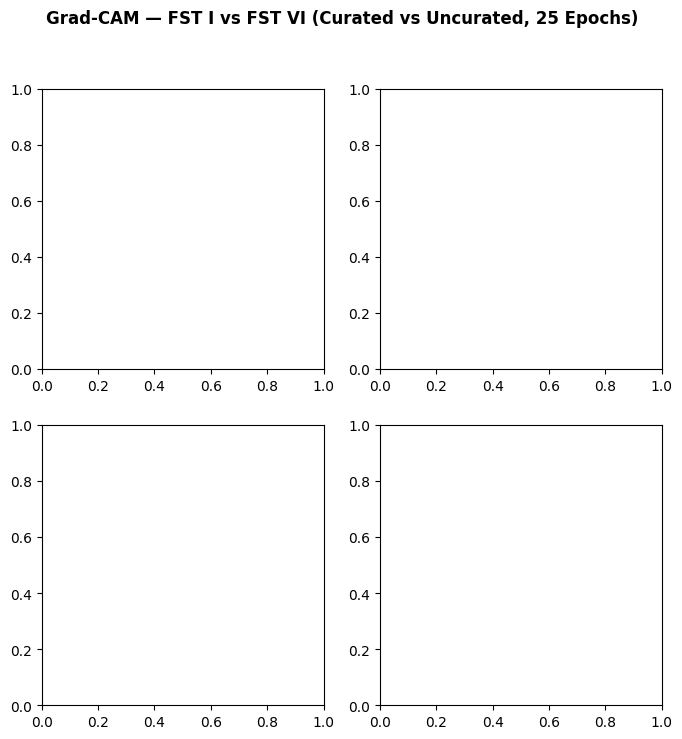

In [20]:
# FST images

FST_IMAGE_DIR = PROJECT_DIR / "skin_type_examples"

FST1_M = FST_IMAGE_DIR / "FST_1_malignant.jpg"
FST6_M = FST_IMAGE_DIR / "FST_6_malignant.png"

# ── LOAD MODELS ───────────────────────────────────────
curated_model = load_model(CURATED_MODEL_PATH)
uncurated_model = load_model(UNCURATED_MODEL_PATH)


# ── BUILD GRADCAM MODELS ─────────────────────────────
def build_grad_model(model):
    last_conv_layer = None

    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break

    if last_conv_layer is None:
        raise ValueError("No convolutional layer was found in the model.")

    return tf.keras.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.outputs[0]],
    )

unc_grad_model = build_grad_model(uncurated_model)
cur_grad_model = build_grad_model(curated_model)


# ── GRADCAM FUNCTION ─────────────────────────────────
def make_gradcam_heatmap(img_array, grad_model):

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)

        # Handle sigmoid vs softmax
        if predictions.shape[-1] == 1:
            class_channel = predictions[:, 0]
        else:
            class_idx = tf.argmax(predictions[0])
            class_channel = predictions[:, class_idx]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    # Confidence
    if predictions.shape[-1] == 1:
        confidence = float(predictions[0][0])
    else:
        idx = tf.argmax(predictions[0])
        confidence = float(predictions[0][idx])

    return heatmap.numpy(), confidence


# ── OVERLAY FUNCTION ─────────────────────────────────
def overlay_gradcam(img_path, grad_model):

    img = load_img(img_path, target_size=IMG_SIZE)
    img_arr = img_to_array(img) / 255.0
    inp = np.expand_dims(img_arr, axis=0)

    heatmap, confidence = make_gradcam_heatmap(inp, grad_model)

    heatmap = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE)
    heatmap = tf.squeeze(heatmap).numpy()

    colored = mpl_cm.jet(heatmap)[:, :, :3]

    # cleaner blending
    overlay = np.clip(img_arr * 0.7 + colored * 0.3, 0, 1)

    return overlay, confidence


# ── GENERATE RESULTS ─────────────────────────────────
# Columns: FST I | FST VI
# Rows: Uncurated | Curated

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

fig.suptitle(
    f"Grad-CAM — FST I vs FST VI "
    f"(Curated vs Uncurated, {EPOCHS} Epochs)",
    fontsize=12,
    fontweight='bold'
)

# ── UNCURATED ROW ──
img_u1, conf_u1 = overlay_gradcam(FST1_M, unc_grad_model)
img_u6, conf_u6 = overlay_gradcam(FST6_M, unc_grad_model)

axes[0, 0].imshow(img_u1)
axes[0, 0].set_title(f'Uncurated — FST I\n{conf_u1*100:.1f}%', fontsize=9)
axes[0, 0].axis('off')

axes[0, 1].imshow(img_u6)
axes[0, 1].set_title(f'Uncurated — FST VI\n{conf_u6*100:.1f}%', fontsize=9)
axes[0, 1].axis('off')

# ── CURATED ROW ──
img_c1, conf_c1 = overlay_gradcam(FST1_M, cur_grad_model)
img_c6, conf_c6 = overlay_gradcam(FST6_M, cur_grad_model)

axes[1, 0].imshow(img_c1)
axes[1, 0].set_title(f'Curated — FST I\n{conf_c1*100:.1f}%', fontsize=9)
axes[1, 0].axis('off')

axes[1, 1].imshow(img_c6)
axes[1, 1].set_title(f'Curated — FST VI\n{conf_c6*100:.1f}%', fontsize=9)
axes[1, 1].axis('off')

# Labels
axes[0, 0].set_ylabel('Uncurated', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Curated', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / f"gradcam_fst_{MODEL_TAG}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()